### **Implementación solución exacta mediante curvas características**

In [ ]:
import numpy as np
import matplotlib.pylab as plt
import time
from IPython.display import clear_output, display

Definición del dominio físico

In [ ]:
xL = 0.0
xR = 4.0

Discretización del dominio y construcción del dominio computacional

In [ ]:
N = 201 # Número de puntos para graficar
x = np.linspace(xL,xR,N)

Definición de condición inicial

In [ ]:
# Definición de una función evaluable en posición x.
def Cond_Inicial(x):
  caso = 1
  match caso:
    case 1:
      q = np.exp(-((x-1.0)**2)/0.1)
    case 2:
      if x<0.7:
        q = 0.0
      elif x<1.3:
        q = 1.0
      else:
        q = 0.0
  return q

# Asignación del valor q(x)
q = np.zeros(N)
for i in range(N):
  q[i] = Cond_Inicial(x[i])

Iniciamos una ventana gráfica para visualizar la condición inicial en el dominio computacional.

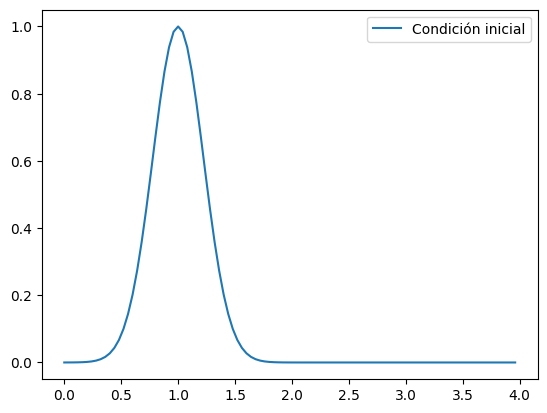

In [ ]:
plt.figure('Condición inicial')
plt.plot(x,q,label='Condición inicial')
plt.legend()

Calculo de la solución exacta al tiempo tfin

In [ ]:
a = 2.0 # Velocidad de propagación
tfin = 1.0 # Tiempo final
q_ex = np.zeros(N)
for i in range(N):
  q_ex[i] = Cond_Inicial(x[i]-a*tfin)

Abrimos una ventana gráfica para visualizar la condición inicial y la solución exacta a tiempo $t=t_{fin}$

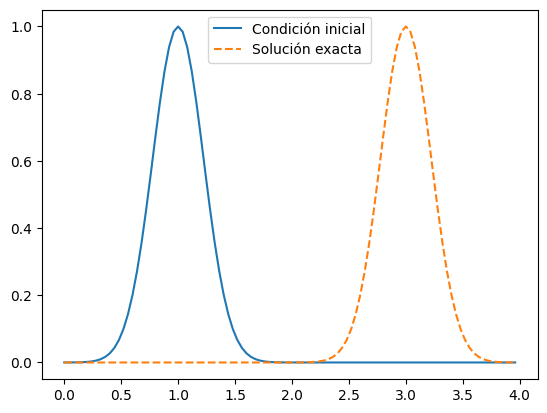

In [ ]:
plt.figure('Solución a tiempo final')
plt.plot(x,q,label='Condición inicial')
plt.plot(x,q_ex,'--',label='Solución exacta')
plt.legend()

**Construcción del método de volúmenes finitos**

In [ ]:
N = 100         # Número de volúmenes finitos
CFL = 0.9       # Número de Courant
dx = (xR-xL)/N  # Paso espacial
dt = CFL*dx/a   # Paso temporal
Time = 0.0      # Tiempo inicial
Tfin = 1.0      # Tiempo final
it = 0          # Contador de pasos temporales

print(f' Time step dt = {dt:.4f}')
x = np.zeros(N)
q = np.zeros(N)

for i in range(N):
  x[i] = xL + i*dx
  q[i] = Cond_Inicial(x[i])

 Time step dt = 0.0180


In [ ]:

def Flux(q,a):
  F = a*q
  return F

def Flux_HLL(qL,qR,a):
  SL = -abs(a)
  SR =  abs(a)
  FL = Flux(qL,a)
  FR = Flux(qR,a)

  F_HLL = (SR*FL-SL*FR+SL*SR*(qR-qL))/(SR-SL)

  if 0 < SL:
    F = FL
  elif SL < 0.0 < SR:
    F = F_HLL
  elif SR > 0:
    F = FR

  return F

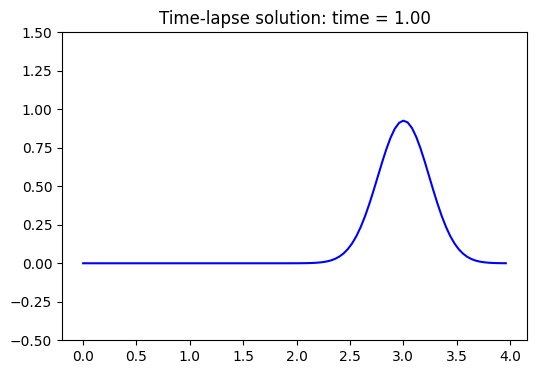

In [ ]:

F = np.zeros(N+1)

while Time < Tfin:
  if Time+dt > Tfin:
    dt = Tfin-Time
  Time = Time + dt

  # Calcula flujos numéricos
  for i in range(N+1):
    if i == 0: # Condición de borde por la izquierda
      qL = q[N-1] # Condición de borde periódica
      qR = q[0]
    elif i == N: # Condición de borde por la derecha
      qL = q[N-1]
      qR = q[0] # Condición de borde periódica
    else:
      qL = q[i-1]
      qR = q[i]

    F[i] = Flux_HLL(qL,qR,a)

  # Actualiza solución
  for i in range(N):
    FL = F[i]
    FR = F[i+1]
    q[i] = q[i] - (dt/dx)*(FR-FL)


  # Create the figure
  fig, ax = plt.subplots(figsize=(6, 4))

  ax.plot(x, q, color="blue")
  ax.set_ylim(-0.5, 1.5)
  ax.set_title(f"Time-lapse solution: time = {Time:.2f}")

  # Clear the previous cell output instantly
  clear_output(wait=True)

  # Display the newly generated figure
  display(fig)
  plt.close(fig)  # Prevents notebook memory leaks

  # Control the "frame rate" (seconds between updates)
  time.sleep(0.1)

Construcción de solución exacta a tiempo final

In [ ]:
N_ex = 1000
x_ex = np.linspace(xL,xR,N_ex)
q_ex = np.zeros(N_ex)
for i in range(N_ex):
  q_ex[i] = Cond_Inicial(x_ex[i]-a*Tfin)

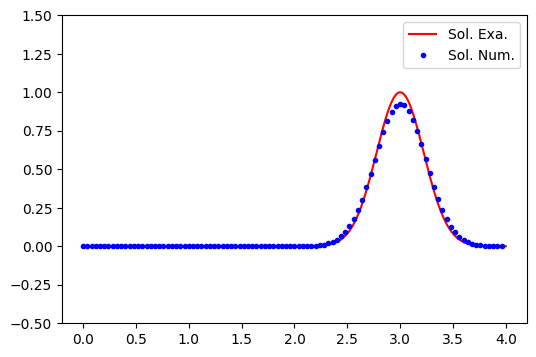

In [ ]:
plt.figure('Solución final',figsize=(6, 4))
plt.clf()
plt.plot(x_ex, q_ex,'-',color="red",label='Sol. Exa.')
plt.plot(x, q,'.',color="blue",label='Sol. Num.')
plt.ylim(-0.5, 1.5)
plt.legend()